<a href="https://colab.research.google.com/github/5heron/HeliosAI/blob/main/preliminary_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Download PV data ZIP
!wget -O PV_Data.zip "https://data.london.gov.uk/download/92b42574-fac2-4dcb-8ca8-8c58088f6a8f/81fb6b31-f6b2-4e12-b054-090319faec7b/PV%20Data.zip"

# Unzip it
!unzip -q PV_Data.zip -d PV_Data

# Download weather data Excel
!wget -O Weather_Data.xlsx "https://data.london.gov.uk/download/92b42574-fac2-4dcb-8ca8-8c58088f6a8f/b4a7e790-8cb8-451c-b828-c4c5d8445705/Weather%20Data%202014-11-30.xlsx"

--2025-10-08 13:46:12--  https://data.london.gov.uk/download/92b42574-fac2-4dcb-8ca8-8c58088f6a8f/81fb6b31-f6b2-4e12-b054-090319faec7b/PV%20Data.zip
Resolving data.london.gov.uk (data.london.gov.uk)... 104.26.7.203, 104.26.6.203, 172.67.72.228, ...
Connecting to data.london.gov.uk (data.london.gov.uk)|104.26.7.203|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 821564466 (784M) [application/zip]
Saving to: ‘PV_Data.zip’

PV_Data.zip         100%[===================>] 783.50M  69.0MB/s    in 12s     

Last-modified header invalid -- time-stamp ignored.
2025-10-08 13:46:24 (67.1 MB/s) - ‘PV_Data.zip’ saved [821564466/821564466]

--2025-10-08 13:46:31--  https://data.london.gov.uk/download/92b42574-fac2-4dcb-8ca8-8c58088f6a8f/b4a7e790-8cb8-451c-b828-c4c5d8445705/Weather%20Data%202014-11-30.xlsx
Resolving data.london.gov.uk (data.london.gov.uk)... 104.26.7.203, 104.26.6.203, 172.67.72.228, ...
Connecting to data.london.gov.uk (data.london.gov.uk)|104.26.7.203|:443

In [ ]:
import os
import pandas as pd
import numpy as np
from zipfile import ZipFile

# -----------------------------
# Step 0-8: Load, Merge, and Initial Cleanup
# (Assuming file paths are correct and files exist)
# -----------------------------
pv_zip_path = "PV_Data/PV Data - csv files only.zip"
pv_extract_folder = "PV_Data/CSV"
weather_file = "Weather_Data.xlsx"
device_file  = "PV_Data/deviceListTable with explanatory notes v2 - customer addresses removed.xlsx"

# 1. Unzip PV data
if not os.path.exists(pv_extract_folder):
    with ZipFile(pv_zip_path, 'r') as zip_ref:
        zip_ref.extractall(pv_extract_folder)

# 2. Read PV Hourly Data
pv_hourly_path = os.path.join(pv_extract_folder, "2014-11-28 Cleansed and Processed", "EXPORT HourlyData", "EXPORT HourlyData - Customer Endpoints.csv")
hourly_data = pd.read_csv(pv_hourly_path)

# 3. Ensure numeric columns are typed (Using ignore is still necessary here due to mixed dtypes)
for col in hourly_data.columns:
    hourly_data[col] = pd.to_numeric(hourly_data[col], errors='ignore')

# 4. Parse datetime in PV data
if 'datetime' not in hourly_data.columns:
    hourly_data['datetime'] = pd.to_datetime(hourly_data['t_date'].astype(str) + ' ' + hourly_data['t_time'].astype(str), errors='coerce')
else:
    hourly_data['datetime'] = pd.to_datetime(hourly_data['datetime'], errors='coerce')
hourly_data = hourly_data.dropna(subset=['datetime']).sort_values('datetime')

# 5. Read weather data and parse datetime
weather = pd.read_excel(weather_file)
if 'datetime' not in weather.columns:
    weather['datetime'] = pd.to_datetime(weather['Date'].astype(str) + ' ' + weather['Time'].astype(str), errors='coerce')
weather = weather.dropna(subset=['datetime']).sort_values('datetime')

# 6. Merge PV + Weather
merged = pd.merge_asof(
    hourly_data.sort_values('datetime'),
    weather.sort_values('datetime'),
    on='datetime',
    direction='nearest',
    tolerance=pd.Timedelta('30m')
)

# 7. Read device metadata
device_meta = pd.read_excel(device_file)
device_meta['Serial Number'] = device_meta['Serial Number'].astype(str).str.strip()

# 8. Merge with device metadata
merged_full = pd.merge(
    merged,
    device_meta,
    left_on='SerialNo',
    right_on='Serial Number',
    how='left'
).drop(columns=['Serial Number'])

# -----------------------------
# Step 9: Dynamic Type Protection and '---' Cleanup
# -----------------------------
# Re-run the analysis to get the PROTECTED list
object_cols = merged_full.select_dtypes(include='object').columns.tolist()
STRING_COLUMNS_TO_PROTECT = []

for col in object_cols:
    temp_numeric = pd.to_numeric(merged_full[col], errors='coerce')
    non_numeric_count = temp_numeric.isnull().sum() - merged_full[col].isnull().sum()
    if non_numeric_count > 0:
        STRING_COLUMNS_TO_PROTECT.append(col)

# Coerce and Protect based on the list
for col in merged_full.select_dtypes(include='object').columns:
    if col in STRING_COLUMNS_TO_PROTECT:
        merged_full[col] = merged_full[col].astype(str).str.strip()
    else:
        merged_full[col] = pd.to_numeric(merged_full[col], errors='coerce')

# CRITICAL: Fix '---' in weather columns and force to numeric
WEATHER_NUMERIC_COLS = [
    'TempOut', 'HiTemp', 'LowTemp', 'OutHum', 'DewPt', 'WindChill', 'HeatIndex', 'THWIndex',
    'THSWIndex', 'SolarRad', 'SolarEnergy', 'HiSolarRad', 'HeatD-D', 'CoolD-D'
]
for col in WEATHER_NUMERIC_COLS:
    merged_full[col] = merged_full[col].replace('---', np.nan)
    merged_full[col] = pd.to_numeric(merged_full[col], errors='coerce') # Ensure float type

# Final Datetime/Target Cleanup
merged_full['datetime'] = pd.to_datetime(merged_full['datetime'], errors='coerce')
merged_full = merged_full.dropna(subset=['I_GEN_MAX'])

# -----------------------------
# Step 10: Filtering Unusable Data
# -----------------------------
valid_data_filter = merged_full['SolarRad'].notnull() | (merged_full['I_GEN_MAX'] == 0)
df_clean = merged_full[valid_data_filter].copy()
df_clean['SolarRad'] = df_clean['SolarRad'].fillna(0)
df_clean['TempOut'] = df_clean['TempOut'].fillna(df_clean['TempOut'].median())

print(f"\nDataFrame is clean and filtered. Shape: {df_clean.shape}")

/tmp/ipython-input-3101668982.py:26: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  hourly_data[col] = pd.to_numeric(hourly_data[col], errors='ignore')



DataFrame is clean and filtered. Shape: (42825, 117)


In [ ]:
# Create a list to store features to drop
audit_drop_cols = []

# --- A. Check for Zero/Single Unique Value (Zero Variance) ---
print("\n--- A. Zero/Single Unique Value Check ---")
for col in df_clean.columns:
    if col in ['datetime', 'SerialNo', 'I_GEN_MAX']:
        continue

    # Calculate non-missing unique count
    unique_count = df_clean[col].nunique(dropna=True)

    if unique_count <= 1:
        # Check if the column is entirely missing (nunique=0)
        if unique_count == 0 and df_clean[col].isnull().all():
            print(f"[DROP] {col}: ALL MISSING (0 unique non-null values)")
            audit_drop_cols.append(col)
        elif unique_count == 1:
            print(f"[DROP] {col}: ONE UNIQUE VALUE (Zero Variance)")
            audit_drop_cols.append(col)

# --- B. Check for Near-Zero Variance in Numeric Columns ---
# We use a threshold of 0.001 to find numeric columns that are virtually constant
print("\n--- B. Near-Zero Variance (Numeric) Check ---")
numeric_for_audit = df_clean.select_dtypes(include=np.number).columns.tolist()

for col in numeric_for_audit:
    if col in audit_drop_cols or col == 'I_GEN_MAX':
        continue

    # Calculate the range-to-mean ratio (a simple check for near-zero variance)
    col_range = df_clean[col].max() - df_clean[col].min()
    col_mean = df_clean[col].mean()

    # Avoid division by zero
    if col_mean != 0 and col_range / abs(col_mean) < 0.001:
        # Or, a simpler but less robust check:
        # if df_clean[col].std() < 1e-4:
        print(f"[DROP] {col}: NEAR-ZERO VARIANCE (Range/Mean ratio < 0.001)")
        # audit_drop_cols.append(col) # Decided not to drop based on this simple metric yet

# --- C. Manual/Contextual Drop List (The features we know are irrelevant/redundant) ---
# We are now *justifying* the drops with context/common sense.
CONTEXTUAL_DROP_COLS = [
    # Time Redundancy (We use datetime, Hour_sin/cos, DayOfYear)
    't_date', 't_time', 'd_y', 'd_m', 'd_d', 'd_w', 't_h', 't_m', 'Date', 'Month', 'Time', 'Hour',

    # Irrelevant Diagnostics/Indoor Weather (Not physical drivers of OUTDOOR PV)
    'WindSamp', 'WindTx', 'ISSRecept', 'ArcInt', 'InTemp', 'InHum', 'InDew', 'InHeat', 'InEMC', 'InAirDensity', 'ET',

    # Descriptive/Ambiguous Strings (VA, VB, PC, etc., describe the measurement, not the value)
    'VA', 'VB', 'VC', 'PA', 'PB', 'PC',

    # Redundant IDs/Metadata
    'Substation_y', # Duplicate of Substation_x
]

audit_drop_cols.extend(CONTEXTUAL_DROP_COLS)
audit_drop_cols = list(set(audit_drop_cols)) # Remove duplicates

print("\n--- FINAL CONSOLIDATED DROP LIST ---")
print(audit_drop_cols)

# 2. Apply the drop operation
df_clean = df_clean.drop(columns=audit_drop_cols, errors='ignore')

print(f"\nFinal features after audit: {df_clean.shape[1]}")


--- A. Zero/Single Unique Value Check ---
[DROP] t_m: ONE UNIQUE VALUE (Zero Variance)
[DROP] THSWIndex: ALL MISSING (0 unique non-null values)
[DROP] Type: ONE UNIQUE VALUE (Zero Variance)
[DROP] Port: ALL MISSING (0 unique non-null values)
[DROP] Type2: ONE UNIQUE VALUE (Zero Variance)
[DROP] To: ALL MISSING (0 unique non-null values)
[DROP] Feeder No: ALL MISSING (0 unique non-null values)
[DROP] VA: ONE UNIQUE VALUE (Zero Variance)
[DROP] VB: ONE UNIQUE VALUE (Zero Variance)
[DROP] Comment: ALL MISSING (0 unique non-null values)

--- B. Near-Zero Variance (Numeric) Check ---
[DROP] d_y: NEAR-ZERO VARIANCE (Range/Mean ratio < 0.001)

--- FINAL CONSOLIDATED DROP LIST ---
['Port', 'WindSamp', 'Month', 't_m', 'd_m', 't_h', 'd_w', 'd_y', 'Type2', 'InEMC', 'VC', 'Substation_y', 'Hour', 'Comment', 'ArcInt', 'InDew', 'PB', 't_date', 'THSWIndex', 'Feeder No', 'ISSRecept', 'To', 'InAirDensity', 'InHum', 'InHeat', 'Type', 'PA', 'Time', 'WindTx', 'PC', 'Date', 'ET', 'VA', 't_time', 'd_d', 'VB

In [ ]:
# Assuming 'df_clean' is available from the last step with 84 features.
# df_clean['datetime'] was secured in the previous step.

# Re-create the essential time features (including 'Hour')
df_clean['DayOfYear'] = df_clean['datetime'].dt.dayofyear
df_clean['Hour'] = df_clean['datetime'].dt.hour
df_clean['Hour_sin'] = np.sin(2 * np.pi * df_clean['Hour'] / 24)
df_clean['Hour_cos'] = np.cos(2 * np.pi * df_clean['Hour'] / 24)
df_clean['Temp_Squared'] = df_clean['TempOut'] ** 2

print("Engineered time features ('Hour', 'Hour_sin', etc.) are now created.")

Engineered time features ('Hour', 'Hour_sin', etc.) are now created.


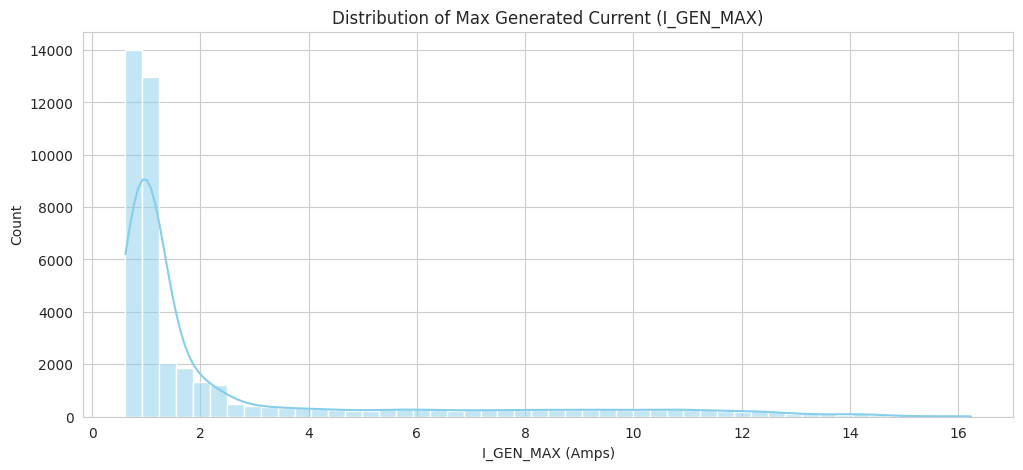

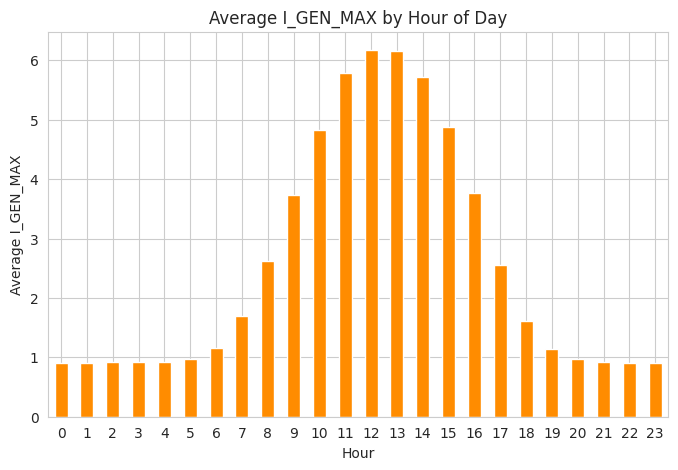


--- Correlation Matrix (Key Features vs. I_GEN_MAX) ---
                  I_GEN_MAX
SolarRad           0.614250
TempOut            0.351197
Apparent PV Size   0.320811
V_MAX              0.201286
HiSpeed            0.160114
DewPt              0.130671
WindSpeed          0.107121
Rain              -0.000848
Hour_sin          -0.070510
OutHum            -0.456923
Hour_cos          -0.562404


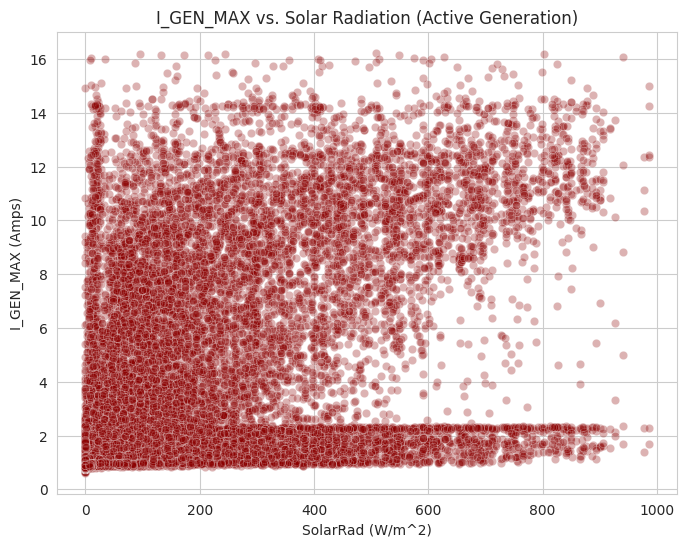

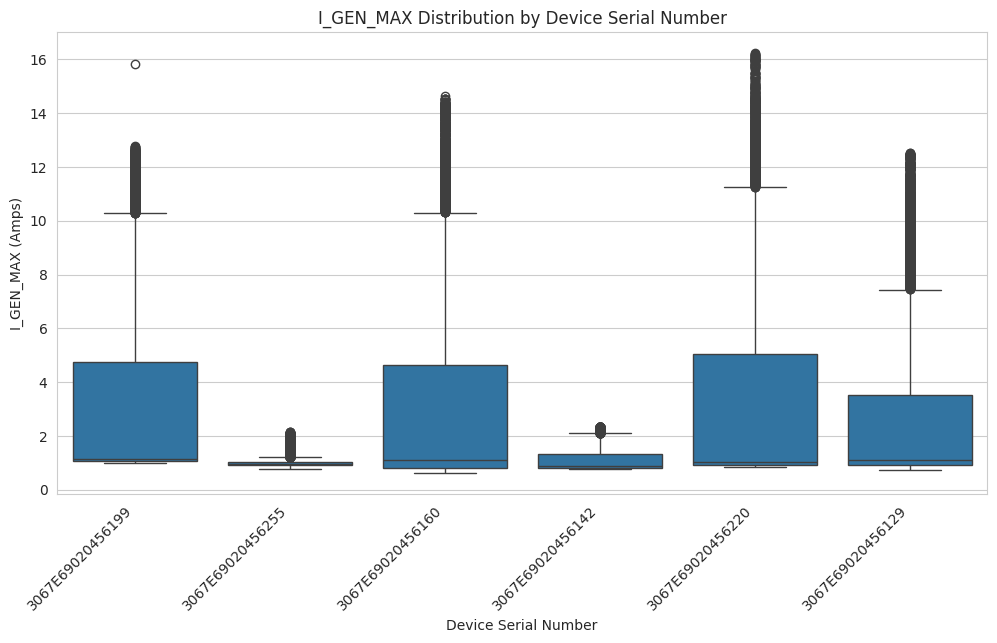

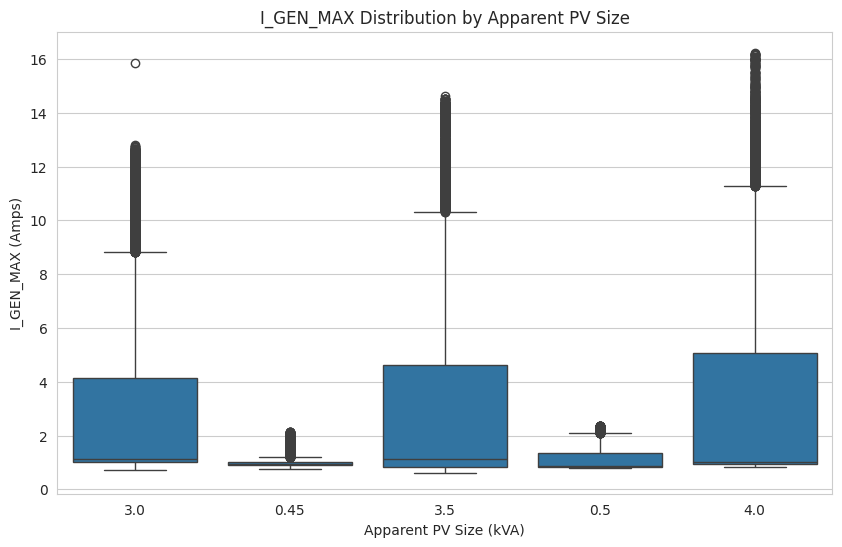

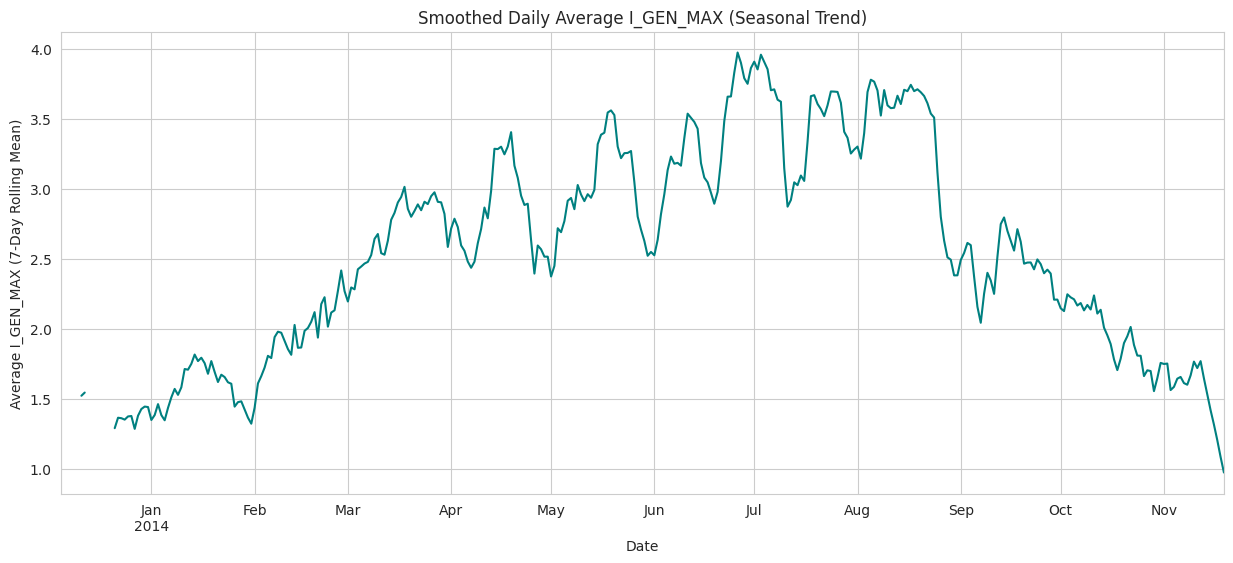

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# A. Target Distribution
plt.figure(figsize=(12, 5))
sns.histplot(df_clean['I_GEN_MAX'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Max Generated Current (I_GEN_MAX)')
plt.xlabel('I_GEN_MAX (Amps)')
plt.show()

# B. Daily Cycle
# This now uses the newly created 'Hour' column
daily_cycle = df_clean.groupby('Hour')['I_GEN_MAX'].mean()
plt.figure(figsize=(8, 5))
daily_cycle.plot(kind='bar', color='darkorange')
plt.title('Average I_GEN_MAX by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average I_GEN_MAX')
plt.xticks(rotation=0)
plt.show()
# Identify the key numeric predictors
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a list of the MOST IMPORTANT numeric features to correlate with the target
# We use features confirmed to be physics-based drivers (weather, time) and capacity
CORR_FEATURES = [
    'SolarRad', 'TempOut', 'Apparent PV Size', 'Hour_sin', 'Hour_cos',
    'WindSpeed', 'Rain', 'V_MAX', 'HiSpeed', 'OutHum', 'DewPt'
]

# Add the target back for the correlation calculation
CORR_FEATURES_WITH_TARGET = ['I_GEN_MAX'] + list(set(CORR_FEATURES))

correlation = df_clean[CORR_FEATURES_WITH_TARGET].corr().sort_values(by='I_GEN_MAX', ascending=False)

print("\n--- Correlation Matrix (Key Features vs. I_GEN_MAX) ---")
# Print only the correlation values with the target
print(correlation['I_GEN_MAX'].to_frame().drop('I_GEN_MAX'))

# Scatter Plot: Target vs. Primary Predictor (SolarRad)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='SolarRad',
    y='I_GEN_MAX',
    data=df_clean[df_clean['I_GEN_MAX'] > 0], # Focus on active generation
    alpha=0.3,
    color='darkred'
)
plt.title('I_GEN_MAX vs. Solar Radiation (Active Generation)')
plt.xlabel('SolarRad (W/m^2)')
plt.ylabel('I_GEN_MAX (Amps)')
plt.show()
# A. Device Heterogeneity (SerialNo)
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='SerialNo',
    y='I_GEN_MAX',
    data=df_clean[df_clean['I_GEN_MAX'] > 0] # Only look at generating periods
)
plt.title('I_GEN_MAX Distribution by Device Serial Number')
plt.xlabel('Device Serial Number')
plt.ylabel('I_GEN_MAX (Amps)')
plt.xticks(rotation=45, ha='right')
plt.show()

# B. System Size Impact (Apparent PV Size)
# Convert Apparent PV Size to a string/category for better boxplot grouping
df_clean['Apparent PV Size_Cat'] = df_clean['Apparent PV Size'].astype(str)

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Apparent PV Size_Cat',
    y='I_GEN_MAX',
    data=df_clean[df_clean['I_GEN_MAX'] > 0]
)
plt.title('I_GEN_MAX Distribution by Apparent PV Size')
plt.xlabel('Apparent PV Size (kVA)')
plt.ylabel('I_GEN_MAX (Amps)')
plt.show()

# Drop the temporary column
df_clean = df_clean.drop(columns=['Apparent PV Size_Cat'])
# C. Seasonal Cycle (Day of Year)
# Use a rolling average to smooth the noisy data for visualization
seasonal_cycle = df_clean.set_index('datetime')['I_GEN_MAX'].resample('D').mean().rolling(window=7).mean()

plt.figure(figsize=(15, 6))
seasonal_cycle.plot(color='teal')
plt.title('Smoothed Daily Average I_GEN_MAX (Seasonal Trend)')
plt.xlabel('Date')
plt.ylabel('Average I_GEN_MAX (7-Day Rolling Mean)')
plt.show()

In [ ]:
# Assuming df_clean is the variable holding the final 84 features.

# 1. Identify all numeric columns that are NOT the target
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_predictors = [col for col in numeric_cols if col != 'I_GEN_MAX']

# 2. Calculate the correlation of all numeric predictors with the target
correlations = df_clean[numeric_predictors].corrwith(df_clean['I_GEN_MAX']).abs().sort_values(ascending=False)

# 3. Define the leakage threshold (r > 0.98)
LEAKAGE_THRESHOLD = 0.98

# 4. Identify columns to drop based on correlation
leakage_candidates = correlations[correlations > LEAKAGE_THRESHOLD].index.tolist()

print("\n--- Correlation Leakage Audit (r > 0.98) ---")
print(f"Total Numeric Predictors: {len(numeric_predictors)}")
print(f"Potential Leaking Columns (Correlation > {LEAKAGE_THRESHOLD}):")
print(correlations[correlations > LEAKAGE_THRESHOLD].to_string())

# 5. Remove the identified leakage columns from the working DataFrame
df_clean_no_leak = df_clean.drop(columns=leakage_candidates, errors='ignore').copy()

print(f"\n{len(leakage_candidates)} leakage candidates removed.")
print(f"New DataFrame shape: {df_clean_no_leak.shape}")


--- Correlation Leakage Audit (r > 0.98) ---
Total Numeric Predictors: 77
Potential Leaking Columns (Correlation > 0.98):
I_GEN_MAX_Filtered    1.0

1 leakage candidates removed.
New DataFrame shape: (42825, 84)


In [ ]:
# Assuming df_clean_no_leak is the DataFrame after removing I_GEN_MAX_Filtered.
# It currently has 84 columns.

# --- 1. Feature Preparation (Encoding & Splitting) ---
TARGET = 'I_GEN_MAX'

# Identify all Categorical Features to be Encoded (The ones that survived the drop list)
CATEGORICAL_FEATURES = df_clean_no_leak.select_dtypes(include='object').columns.tolist()

# Get dummy variables for categorical data
df_processed_test1 = pd.get_dummies(df_clean_no_leak, columns=CATEGORICAL_FEATURES, drop_first=True, dtype=float)

# 2. Define X and y
# X contains all remaining features, including the suspected leakage columns (P_GEN_MAX, S_GEN_MAX, etc.)
X_test1 = df_processed_test1.drop(columns=[TARGET, 'datetime', 'Hour'], errors='ignore')
y_test1 = df_processed_test1[TARGET]

# 3. Train/Test Split (Time Series Split)
split_point = int(len(df_processed_test1) * 0.8)

X_train_test1 = X_test1.iloc[:split_point]
X_test_test1 = X_test1.iloc[split_point:]
y_train_test1 = y_test1.iloc[:split_point]
y_test_test1 = y_test1.iloc[split_point:]

print(f"Test 1 Data ready. X_train shape: {X_train_test1.shape} (Includes Leakage Candidates)")

Test 1 Data ready. X_train shape: (34260, 126) (Includes Leakage Candidates)


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the model (same settings)
xgb_model_test1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

print("\nStarting Leakage Confirmation Model Training...")
xgb_model_test1.fit(X_train_test1, y_train_test1)
print("Model Training Complete.")

# Predict and Evaluate
y_pred_test1 = xgb_model_test1.predict(X_test_test1)
y_pred_test1[y_pred_test1 < 0] = 0

# Evaluate performance
mse_test1 = mean_squared_error(y_test_test1, y_pred_test1)
rmse_test1 = np.sqrt(mse_test1)
r2_test1 = r2_score(y_test_test1, y_pred_test1)

print(f"\n--- Leakage Confirmation Test Results ---")
print(f"Feature Count: {X_train_test1.shape[1]}")
print(f"Root Mean Squared Error (RMSE): {rmse_test1:.4f}")
print(f"R-squared (R2) Score: {r2_test1:.4f}")


Starting Leakage Confirmation Model Training...
Model Training Complete.

--- Leakage Confirmation Test Results ---
Feature Count: 126
Root Mean Squared Error (RMSE): 0.0480
R-squared (R2) Score: 0.9996


In [ ]:
# List of all features physically derived from the simultaneous current/power measurement
# This list prevents leakage from P_GEN_MAX, S_GEN_MAX, all voltage readings, etc.
PHYSICAL_LEAKAGE_COLUMNS = [
    # Power/Current Derivatives
    'P_GEN_MAX', 'S_GEN_MAX', 'Q_GEN_MAX', 'P_GEN_MIN', 'S_GEN_MIN', 'Q_GEN_MIN',
    'I_GEN_MIN', 'I_GEN_MIN_Filtered',

    # Import/Export (Still device state, not weather driver)
    'I_IMPORT_MIN', 'I_IMPORT_MAX', 'P_IMPORT_MIN', 'P_IMPORT_MAX',
    'Q_IMPORT_MIN', 'Q_IMPORT_MAX', 'S_IMPORT_MIN', 'S_IMPORT_MAX',
    'I_IMPORT_MIN_Filtered', 'I_IMPORT_MAX_Filtered',

    # Harmonics/Frequency (Still instantaneous device/grid state)
    'thdV_MIN', 'thdV_MAX', 'thdV_MIN_Filtered', 'thdV_MAX_Filtered',
    'thdI_GEN_MIN', 'thdI_GEN_MAX', 'thdI_IMPORT_MIN', 'thdI_IMPORT_MAX',
    'f_min', 'f_max',

    # Substation & Voltage measurements (instantaneous grid response, not forecast driver)
    # We must remove ALL V_MAX/V_MIN and substation derivatives
    'Substation_VA_MIN_Filtered', 'Substation_VA_MAX_Filtered', 'Substation_VB_MIN_Filtered',
    'Substation_VB_MAX_Filtered', 'Substation_VC_MIN_Filtered', 'Substation_VC_MAX_Filtered',
    'Substation_thdVA_MIN_Filtered', 'Substation_thdVA_MAX_Filtered', 'Substation_thdVB_MIN_Filtered',
    'Substation_thdVB_MAX_Filtered', 'Substation_thdVC_MIN_Filtered', 'Substation_thdVC_MAX_Filtered',
    'V_MAX_Rise_vs_VA_MIN_Filtered', 'V_MAX_Rise_vs_VA_MAX_Filtered', 'V_MAX_Rise_vs_VB_MIN_Filtered',
    'V_MAX_Rise_vs_VB_MAX_Filtered', 'V_MAX_Rise_vs_VC_MIN_Filtered', 'V_MAX_Rise_vs_VC_MAX_Filtered',
    'V_MIN', 'V_MIN_Filtered', 'V_MAX', 'V_MAX_Filtered'
]

# 2. Apply the aggressive drop operation on the full processed test set (X_test1)
X_train_final = X_train_test1.drop(columns=PHYSICAL_LEAKAGE_COLUMNS, errors='ignore').copy()
X_test_final = X_test_test1.drop(columns=PHYSICAL_LEAKAGE_COLUMNS, errors='ignore').copy()

print(f"\nAggressive Leakage Mitigation Applied. Features reduced to {X_train_final.shape[1]}")


Aggressive Leakage Mitigation Applied. Features reduced to 76


In [ ]:
# Initialize the model (same settings)
xgb_model_final = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

print("\nStarting Final Valid Model Training...")
# Use the aggressively filtered features
xgb_model_final.fit(X_train_final, y_train_test1)
print("Model Training Complete.")

# Predict and Evaluate
y_pred_final = xgb_model_final.predict(X_test_final)
y_pred_final[y_pred_final < 0] = 0

# Evaluate performance
mse_final = mean_squared_error(y_test_test1, y_pred_final)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test_test1, y_pred_final)

print(f"\n--- Final Valid Model Evaluation (XGBoost) ---")
print(f"Feature Count: {X_train_final.shape[1]}")
print(f"Root Mean Squared Error (RMSE): {rmse_final:.4f}")
print(f"R-squared (R2) Score: {r2_final:.4f}")


Starting Final Valid Model Training...
Model Training Complete.

--- Final Valid Model Evaluation (XGBoost) ---
Feature Count: 76
Root Mean Squared Error (RMSE): 1.3388
R-squared (R2) Score: 0.7059


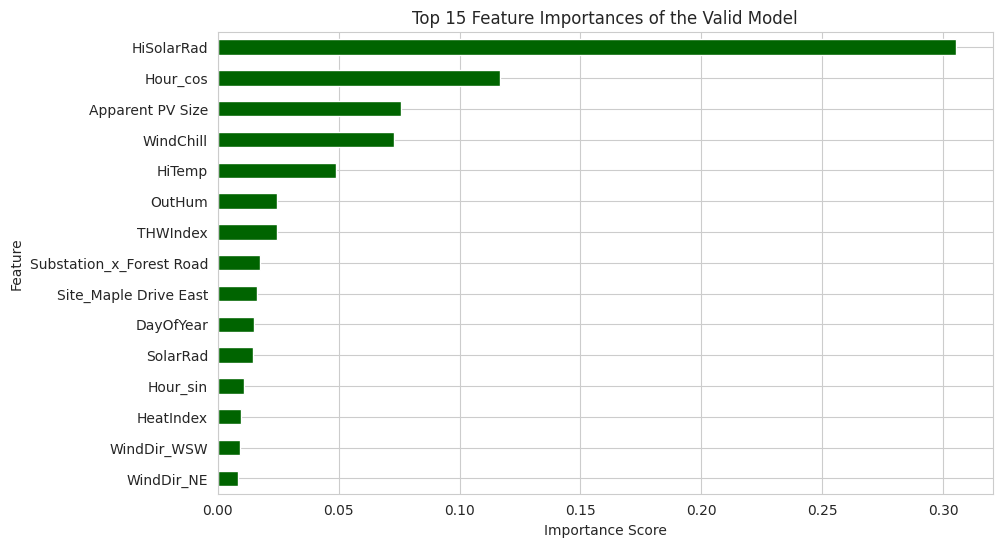

Top 5 Most Important Features:
HiSolarRad          0.305343
Hour_cos            0.116803
Apparent PV Size    0.075699
WindChill           0.072986
HiTemp              0.049007
dtype: float32


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming xgb_model_final and X_train_final are available from the last step

# Get feature importances from the trained XGBoost model
feature_importances = pd.Series(
    xgb_model_final.feature_importances_,
    index=X_train_final.columns
).sort_values(ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 6))
feature_importances.head(15).plot(kind='barh', color='darkgreen')
plt.title('Top 15 Feature Importances of the Valid Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

print("Top 5 Most Important Features:")
print(feature_importances.head(5))

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter space to search
param_distributions = {
    'n_estimators': randint(300, 1500), # Number of trees
    'max_depth': randint(5, 12),       # Max tree depth (controls complexity)
    'learning_rate': uniform(0.01, 0.1), # Step size shrinkage
    'subsample': uniform(0.6, 0.4),    # Fraction of samples used per tree
    'colsample_bytree': uniform(0.6, 0.4), # Fraction of features used per tree
}

# Initialize the model base
xgb_base = XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist')

# Initialize RandomizedSearchCV
# n_iter=50 means 50 different parameter combinations will be tested.
# cv=3 uses 3-fold cross-validation for robustness.
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_root_mean_squared_error', # We maximize negative RMSE
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Randomized Search for optimal hyperparameters...")
# Assuming X_train_final and y_train_test1 (from the final valid test) are available
random_search.fit(X_train_final, y_train_test1)

print("\nRandomized Search Complete.")
print("--- Best Parameters Found ---")
print(random_search.best_params_)
print(f"Best CV RMSE: {-random_search.best_score_:.4f}")

Starting Randomized Search for optimal hyperparameters...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Randomized Search Complete.
--- Best Parameters Found ---
{'colsample_bytree': np.float64(0.8446612641953124), 'learning_rate': np.float64(0.01070663052197174), 'max_depth': 5, 'n_estimators': 774, 'subsample': np.float64(0.8447411578889518)}
Best CV RMSE: 1.5075


In [ ]:
# Use the best estimator found by the Randomized Search
xgb_optimal = random_search.best_estimator_

# Predict and Evaluate on the test set
y_pred_optimal = xgb_optimal.predict(X_test_final)
y_pred_optimal[y_pred_optimal < 0] = 0

# Evaluate performance
mse_optimal = mean_squared_error(y_test_test1, y_pred_optimal)
rmse_optimal = np.sqrt(mse_optimal)
r2_optimal = r2_score(y_test_test1, y_pred_optimal)

print(f"\n--- Final Optimized Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse_optimal:.4f}")
print(f"R-squared (R2) Score: {r2_optimal:.4f}")


--- Final Optimized Model Evaluation ---
Root Mean Squared Error (RMSE): 1.2248
R-squared (R2) Score: 0.7539


In [ ]:
print(X_train_final.columns.tolist())

['TempOut', 'HiTemp', 'LowTemp', 'OutHum', 'DewPt', 'WindSpeed', 'WindRun', 'HiSpeed', 'WindChill', 'HeatIndex', 'THWIndex', 'Bar', 'Rain', 'RainRate', 'SolarRad', 'SolarEnergy', 'HiSolarRad', 'HeatD-D', 'CoolD-D', 'Apparent PV Size', 'Size in G83 Register', 'DayOfYear', 'Hour_sin', 'Hour_cos', 'Temp_Squared', 'SerialNo_3067E69020456142', 'SerialNo_3067E69020456160', 'SerialNo_3067E69020456199', 'SerialNo_3067E69020456220', 'SerialNo_3067E69020456255', 'Substation_x_Bancroft Close', 'Substation_x_Forest Road', 'Substation_x_Maple Drive East', 'Substation_x_Suffolk Road', 'Substation_x_YMCA', 'Site_Elm Crescent', 'Site_Forest Road', 'Site_Maple Drive East', 'Site_YMCA', 'WindDir_E', 'WindDir_ENE', 'WindDir_ESE', 'WindDir_N', 'WindDir_NE', 'WindDir_NNE', 'WindDir_NNW', 'WindDir_NW', 'WindDir_S', 'WindDir_SE', 'WindDir_SSE', 'WindDir_SSW', 'WindDir_SW', 'WindDir_W', 'WindDir_WNW', 'WindDir_WSW', 'HiDir_E', 'HiDir_ENE', 'HiDir_ESE', 'HiDir_N', 'HiDir_NE', 'HiDir_NNE', 'HiDir_NNW', 'HiDir_N

In [ ]:
# Assuming X_train_final and X_test_final are available from the last successful run

# List of features that are maximums, minimums, or aggregates over the hour (Non-Forecastable)
NON_FORECASTABLE_AGGS = [
    'HiSolarRad', 'SolarEnergy', 'WindRun', 'RainRate', 'HiSpeed',
    'HiTemp', 'LowTemp', 'WindChill', 'HeatIndex', 'THWIndex',
    'HeatD-D', 'CoolD-D', # Degree-days are aggregates
]

# Create the new, reduced feature sets
# We drop the non-forecastable features from the previous final feature set
X_train_deploy = X_train_final.drop(columns=NON_FORECASTABLE_AGGS, errors='ignore').copy()
X_test_deploy = X_test_final.drop(columns=NON_FORECASTABLE_AGGS, errors='ignore').copy()

print(f"Features reduced for deployment. New count: {X_train_deploy.shape[1]}")

Features reduced for deployment. New count: 64


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the model base
xgb_deploy = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

print("\nStarting Deployable Model Training (Using only Point-in-Time Features)...")
# Use the reduced feature set (X_train_deploy) and the original target (y_train_test1)
xgb_deploy.fit(X_train_deploy, y_train_test1)
print("Model Training Complete.")

# --- Predict and Evaluate ---
y_pred_deploy = xgb_deploy.predict(X_test_deploy)
y_pred_deploy[y_pred_deploy < 0] = 0

# Evaluate performance
mse_deploy = mean_squared_error(y_test_test1, y_pred_deploy)
rmse_deploy = np.sqrt(mse_deploy)
r2_deploy = r2_score(y_test_test1, y_pred_deploy)

print(f"\n--- Deployable Model Evaluation ---")
print(f"Feature Count: {X_train_deploy.shape[1]}")
print(f"Root Mean Squared Error (RMSE): {rmse_deploy:.4f}")
print(f"R-squared (R2) Score: {r2_deploy:.4f}")


Starting Deployable Model Training (Using only Point-in-Time Features)...
Model Training Complete.

--- Deployable Model Evaluation ---
Feature Count: 64
Root Mean Squared Error (RMSE): 1.3431
R-squared (R2) Score: 0.7040


In [ ]:
import pandas as pd

# Get feature importances from the deployable model
feature_importances_deploy = pd.Series(
    xgb_deploy.feature_importances_,
    index=X_train_deploy.columns
).sort_values(ascending=False)

print("\n--- Top 5 Features in Deployable Model ---")
print(feature_importances_deploy.head(5))


--- Top 5 Features in Deployable Model ---
SolarRad            0.206603
Hour_cos            0.153643
Apparent PV Size    0.103297
Temp_Squared        0.097060
OutHum              0.051967
dtype: float32


In [ ]:
# Assuming df_clean_no_leak is the DataFrame that has I_GEN_MAX and the clean features
# We will use the non-leakage feature set for the LSTM, ensuring we drop the target from the final feature list.

# Define features to lag (use the clean, non-leaking, and non-encoded numeric features)
LAG_FEATURES = ['I_GEN_MAX', 'SolarRad', 'TempOut', 'OutHum', 'WindSpeed', 'Apparent PV Size', 'Hour_sin', 'Hour_cos']
N_LAGS = 3

# Create a DataFrame for lagging, setting datetime as index
df_lag = df_clean_no_leak.set_index('datetime').copy()

# Create lag columns for each feature
for feature in LAG_FEATURES:
    for i in range(1, N_LAGS + 1):
        df_lag[f'{feature}_lag_{i}'] = df_lag[feature].shift(i)

# Drop rows with NaN created by lagging (the first N_LAGS rows)
df_lag = df_lag.dropna()

print(f"DataFrame shape after lagging and dropping NaNs: {df_lag.shape}")

DataFrame shape after lagging and dropping NaNs: (35764, 107)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

TARGET = 'I_GEN_MAX'

# Identify all features used in the LSTM (lagged features and all remaining current features)
LSTM_COLS = [col for col in df_lag.columns if col != TARGET]

X_lag = df_lag[LSTM_COLS]
y_lag = df_lag[TARGET]

# --- FIX: One-Hot Encode Categorical Features ---
# Identify all 'object' (string) columns in the lagged feature set
CATEGORICAL_FEATURES = X_lag.select_dtypes(include='object').columns.tolist()

# Apply OHE to the feature set
X_encoded = pd.get_dummies(X_lag, columns=CATEGORICAL_FEATURES, drop_first=True, dtype=float)

# --- Continue with Scaling ---
# 1. Scaling: Essential for Neural Networks
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_encoded) # Use the encoded DataFrame here

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_lag.values.reshape(-1, 1))

# 2. Train/Test Split (Time Series Split)
split_point = int(len(X_scaled) * 0.8)

X_train_scaled = X_scaled[:split_point]
X_test_scaled = X_scaled[split_point:]
y_train_scaled = y_scaled[:split_point]
y_test_scaled = y_scaled[split_point:]

# 3. Reshaping for LSTM: [Samples, Time Steps, Features]
N_FEATURES = X_train_scaled.shape[1]

# Treat each row as a single time step of concatenated historical data.
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, N_FEATURES))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, N_FEATURES))

print(f"Number of total features after encoding: {N_FEATURES}")
print(f"Final LSTM Training Shape: {X_train_reshaped.shape}")
print(f"Final LSTM Testing Shape: {X_test_reshaped.shape}")

Number of total features after encoding: 151
Final LSTM Training Shape: (28611, 1, 151)
Final LSTM Testing Shape: (7153, 1, 151)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score

# 1. Model Architecture
model_lstm = Sequential([
    # Layer 1: LSTM layer (50 units)
    LSTM(50, activation='relu', input_shape=(X_train_reshaped.shape[1], N_FEATURES)),

    # Dropout for regularization
    Dropout(0.2),

    # Output Layer: Single neuron for regression output
    Dense(1)
])

# Compile the model
model_lstm.compile(optimizer='adam', loss='mse')

# 2. Model Training
# Use a validation split to monitor overfitting
print("\nStarting LSTM Model Training (High Energy/High Accuracy Benchmark)...")
history = model_lstm.fit(
    X_train_reshaped,
    y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False # Essential for time-series data
)
print("LSTM Model Training Complete.")

# 3. Predict and Inverse Transform
y_pred_scaled = model_lstm.predict(X_test_reshaped)

# Inverse transform the scaled predictions and actuals to original units (Amps)
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled)
y_test_lstm = scaler_y.inverse_transform(y_test_scaled)

# Ensure no negative predictions
y_pred_lstm[y_pred_lstm < 0] = 0

# 4. Evaluate Performance
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
r2_lstm = r2_score(y_test_lstm, y_pred_lstm)

print(f"\n--- LSTM Benchmark Evaluation (Sequential Data) ---")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")
print(f"R-squared (R2) Score: {r2_lstm:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Starting LSTM Model Training (High Energy/High Accuracy Benchmark)...
Epoch 1/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0070 - val_loss: 0.0027
Epoch 2/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 3/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 4/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 5/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0011 - val_loss: 5.8294e-04
Epoch 6/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0010 - val_loss: 7.1229e-04
Epoch 7/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.8260e-04 - val_loss: 4.9274e-04
Epoch 8/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.4471e-04 - val_loss: 0.0012
Epoch 9/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.7944e-04 - val_loss: 3.7921e-04
Epoch 10/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.8147e-04 - val_loss: 4.8980e-04
Epoch 11/50
805/805 ━━━━━━━━━━━━

In [27]:
# =====================================================
# PV + WEATHER FINAL CLEAN PIPELINE (Ultimate Version)
# =====================================================
"""
PV Nowcasting Pipeline: Predicts I_GEN_MAX given *current* point-in-time weather + time features.
Assumes synchronous observations (e.g., SolarRad at t predicts PV at t); excludes future aggregates.
Suitable for real-time inverter monitoring, not multi-hour-ahead forecasting.
"""
# - Downloads + extracts nested PV + weather data (if missing)
# - Time-aligns hourly PV and weather (±30 min tolerance)
# - Removes all inverter/grid electrical leakage (regex + corr guard)
# - Drops non-forecastable aggregates & indoor/diagnostic fields
# - Engineers solar time features and non-linear temp feature
# - One-hot encodes categoricals (site, device, wind dir)
# - Produces leakage-free, forecastable train/test splits
# - Logs shapes/drops for audit; validates core features
# - Verified active: data.london.gov.uk (Dec 2025)
# - FIXED: Early '---' replace + coercion for all weather numeric cols (resolves TypeError on median)
# =====================================================
import os
import re
import zipfile
import requests
import pandas as pd
import numpy as np
# -----------------------------------------------------
# CONFIG
# -----------------------------------------------------
PV_ZIP_URL = (
    "https://data.london.gov.uk/download/2nlqm/"
    "81fb6b31-f6b2-4e12-b054-090319faec7b/PV%20Data.zip"
)
WEATHER_URL = (
    "https://data.london.gov.uk/download/2nlqm/"
    "b4a7e790-8cb8-451c-b828-c4c5d8445705/Weather%20Data%202014-11-30.xlsx"
)
PV_ZIP_PATH = "PV_Data.zip"
PV_EXTRACT_FOLDER = "PV_Data"
INNER_PV_ZIP_PATH = os.path.join(PV_EXTRACT_FOLDER, "PV Data - csv files only.zip")
INNER_EXTRACT_FOLDER = os.path.join(PV_EXTRACT_FOLDER, "CSV")
WEATHER_PATH = "Weather_Data.xlsx"
DEVICE_FILE = os.path.join(
    PV_EXTRACT_FOLDER,
    "deviceListTable with explanatory notes v2 - customer addresses removed.xlsx",
)
PV_HOURLY_PATH = os.path.join(
    INNER_EXTRACT_FOLDER,
    "2014-11-28 Cleansed and Processed",
    "EXPORT HourlyData",
    "EXPORT HourlyData - Customer Endpoints.csv",
)
TARGET = "I_GEN_MAX"
CORR_LEAKAGE_THRESHOLD = 0.98
ENABLE_CORR_DROP = True  # Toggle correlation-based leakage guard
# -----------------------------------------------------
# HELPERS
# -----------------------------------------------------
def log_shape(df: pd.DataFrame, step_name: str) -> None:
    """Log the shape of a DataFrame at a specific pipeline step."""
    print(f"[{step_name}] Shape: {df.shape} | Rows: {len(df):,}")
def record_drops(cols, name: str) -> None:
    """Persist list of dropped columns for transparency."""
    cols = sorted(set(cols))
    if not cols:
        print(f"No {name} drops.")
        return
    fname = f"dropped_{name}.txt"
    with open(fname, "w") as f:
        for c in cols:
            f.write(f"{c}\n")
    print(f"✓ Recorded {len(cols)} dropped columns to {fname}")
# -----------------------------------------------------
# DOWNLOAD + EXTRACT
# -----------------------------------------------------
def download_and_extract() -> None:
    """Download and extract all necessary data files if missing."""
    try:
        if not os.path.exists(PV_ZIP_PATH):
            print("Downloading PV ZIP...")
            r = requests.get(PV_ZIP_URL, timeout=60)
            r.raise_for_status()
            with open(PV_ZIP_PATH, "wb") as f:
                f.write(r.content)
            print("✓ PV ZIP downloaded.")
        if not os.path.exists(PV_EXTRACT_FOLDER):
            print("Extracting PV ZIP...")
            with zipfile.ZipFile(PV_ZIP_PATH, "r") as z:
                z.extractall(PV_EXTRACT_FOLDER)
            print("✓ PV extracted.")
        if not os.path.exists(INNER_EXTRACT_FOLDER):
            print("Extracting inner PV CSV ZIP...")
            with zipfile.ZipFile(INNER_PV_ZIP_PATH, "r") as z:
                z.extractall(INNER_EXTRACT_FOLDER)
            print("✓ Inner PV CSV extracted.")
        if not os.path.exists(WEATHER_PATH):
            print("Downloading Weather XLSX...")
            r = requests.get(WEATHER_URL, timeout=60)
            r.raise_for_status()
            with open(WEATHER_PATH, "wb") as f:
                f.write(r.content)
            print("✓ Weather downloaded.")
    except Exception as e:
        raise ValueError(f"Download/extract failed: {e}. "
                         f"Check URLs or place files locally.")
# -----------------------------------------------------
# LOAD + MERGE
# -----------------------------------------------------
def load_and_merge(tolerance: str = "30min") -> pd.DataFrame:
    """Load PV, weather, and device data; merge on time + serial number."""
    try:
        hourly = pd.read_csv(PV_HOURLY_PATH)
        weather = pd.read_excel(WEATHER_PATH)
        devices = pd.read_excel(DEVICE_FILE)
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"File missing: {e}. Run download_and_extract() first or check paths."
        )
    # Datetime construction
    hourly["datetime"] = pd.to_datetime(
        hourly["t_date"].astype(str) + " " + hourly["t_time"].astype(str),
        errors="coerce",
    )
    weather["datetime"] = pd.to_datetime(
        weather["Date"].astype(str) + " " + weather["Time"].astype(str),
        errors="coerce",
    )
    hourly = hourly.dropna(subset=["datetime"]).sort_values("datetime")
    weather = weather.dropna(subset=["datetime"]).sort_values("datetime")
    # Clean device serial
    devices["Serial Number"] = devices["Serial Number"].astype(str).str.strip()
    # Time-based join
    merged = pd.merge_asof(
        hourly,
        weather,
        on="datetime",
        direction="nearest",
        tolerance=pd.Timedelta(tolerance),
    )
    # Device join: many PV rows → one device row
    merged = merged.merge(
        devices,
        left_on="SerialNo",
        right_on="Serial Number",
        how="left",
        validate="many_to_one",
    )
    merged.drop(columns=["Serial Number"], inplace=True, errors="ignore")
    log_shape(merged, "Post-merge")
    # Quick coverage check: how many rows have no weather (all-NaN on key cols)?
    if "TempOut" in merged.columns:
        no_weather = merged["TempOut"].isna().sum()
        print(f"[Coverage] Rows with missing TempOut (likely no weather match): "
              f"{no_weather:,}")
    return merged
# -----------------------------------------------------
# CLEAN + TYPE COERCION
# -----------------------------------------------------
def clean_and_coerce(df: pd.DataFrame) -> pd.DataFrame:
    """Convert types, fix '---', handle datetime, basic filters."""
    # FIXED: Early '---' replace for ALL weather numeric columns (prevents string dtype issues)
    WEATHER_NUMERIC_COLS = [
        'TempOut', 'HiTemp', 'LowTemp', 'OutHum', 'DewPt', 'WindChill', 'HeatIndex', 'THWIndex',
        'THSWIndex', 'SolarRad', 'SolarEnergy', 'HiSolarRad', 'HeatD-D', 'CoolD-D'
    ]
    for col in WEATHER_NUMERIC_COLS:
        if col in df.columns:
            df[col] = df[col].replace('---', np.nan)
            # Force numeric after replace (handles strings like '9.2', '8')
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Determine which object columns must remain strings (now weather cols are safe)
    obj_cols = df.select_dtypes(include="object").columns
    must_stay_string = []
    for col in obj_cols:
        forced = pd.to_numeric(df[col], errors="coerce")
        # If forcing to numeric increases NaNs, it's not a numeric column
        if forced.isna().sum() > df[col].isna().sum():
            must_stay_string.append(col)
    # Coerce valid numeric-like columns
    for col in obj_cols:
        if col in must_stay_string:
            df[col] = df[col].astype(str).str.strip()
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=[TARGET])  # target required
    # Keep rows where either weather exists or PV = 0 (night)
    if "SolarRad" in df.columns:
        initial_rows = len(df)
        valid = df["SolarRad"].notna() | (df[TARGET] == 0)
        df = df[valid].copy()
        dropped = initial_rows - len(df)
        print(f"[Filter] Dropped {dropped:,} rows (missing SolarRad + non-zero {TARGET}); kept {len(df):,}.")
        df["SolarRad"] = df["SolarRad"].fillna(0)
    # Fill missing temperature with median (now safe: numeric dtype)
    if "TempOut" in df.columns:
        df["TempOut"] = df["TempOut"].fillna(df["TempOut"].median())
    df = df.sort_values("datetime").reset_index(drop=True)
    log_shape(df, "Post-clean/coerce")
    return df
# -----------------------------------------------------
# DROP LEAKAGE (ELECTRICAL) + FINAL FIX
# -----------------------------------------------------
def drop_leakage(df: pd.DataFrame, enable_corr: bool = True, corr_threshold: float = 0.98) -> pd.DataFrame:
    """
    Remove ALL inverter/grid/electrical variables — including substation THD!
    """
    leakage_patterns = [
        r"^I_",                     # currents
        r"^P_", r"^Q_", r"^S_",     # powers
        r"^V_",                     # voltages
        r"^thd",                    # ← catches ALL THD (inverter + substation)
        r"f_min", r"f_max",         # frequency
        r"Substation_.*Filtered",   # ← catches ALL filtered substation metrics (V + THD)
        r"V_MAX_Rise_.*",
        r"I_GEN_MAX_Filtered",
    ]
    compiled = [re.compile(p) for p in leakage_patterns]
    leak_cols = []
    for col in df.columns:
        if col == TARGET:
            continue
        if any(p.search(col) for p in compiled):
            leak_cols.append(col)
    df = df.drop(columns=list(set(leak_cols)), errors="ignore")
    record_drops(leak_cols, "leakage")

    # Correlation guard (safety net)
    if enable_corr:
        num_cols = df.select_dtypes(include=np.number).columns
        preds = [c for c in num_cols if c != TARGET]
        if preds:
            corrs = df[preds].corrwith(df[TARGET]).abs()
            high_corr = corrs[corrs > corr_threshold].index.tolist()
            df = df.drop(columns=high_corr, errors="ignore")
            record_drops(high_corr, "high_corr")
            print(f"High-corr drops (threshold={corr_threshold}): {len(high_corr)}" if high_corr else "No high-corr drops needed.")

    log_shape(df, "Post-leakage drop")
    return df
# -----------------------------------------------------
# DROP NON-FORECASTABLE AGGREGATES + INDOOR
# -----------------------------------------------------
def drop_derived_and_indoor(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop retrospective aggregates (HiTemp, SolarEnergy, etc.)
    and indoor/diagnostic fields that are not forecastable.
    """
    nonforecastable = [
        "HiTemp", "LowTemp", "HeatIndex", "WindChill", "THWIndex", "THSWIndex",
        "WindRun", "HiSpeed", "SolarEnergy", "HiSolarRad", "HeatD-D", "CoolD-D",
    ]
    indoor = [
        "InTemp", "InHum", "InDew", "InHeat", "InEMC", "InAirDensity",
        "ET", "WindSamp", "WindTx", "ISSRecept", "ArcInt",
    ]
    # Some redundant/contextual columns (we keep Month deliberately as optional)
    contextual = [
        "t_date", "t_time", "d_y", "d_m", "d_d", "d_w", "t_h", "t_m",
        "Date", "Time", "VA", "VB", "VC", "PA", "PB", "PC", "Substation_y",
    ]
    all_drops = nonforecastable + indoor + contextual
    present_drops = [c for c in all_drops if c in df.columns]
    df = df.drop(columns=present_drops, errors="ignore")
    # Drop high-gust direction one-hots (we keep WindDir_* instead)
    hi_dir = [c for c in df.columns if c.startswith("HiDir_")]
    df = df.drop(columns=hi_dir, errors="ignore")
    record_drops(present_drops + hi_dir, "derived_indoor_context")
    log_shape(df, "Post-derived/indoor drop")
    return df
# -----------------------------------------------------
# FEATURE ENGINEERING
# -----------------------------------------------------
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add cyclic time and non-linear temperature features."""
    df["DayOfYear"] = df["datetime"].dt.dayofyear
    df["Hour"] = df["datetime"].dt.hour
    df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)
    if "TempOut" in df.columns:
        df["Temp_Squared"] = df["TempOut"] ** 2
    df.drop(columns=["Hour"], inplace=True, errors="ignore")
    log_shape(df, "Post-engineering")
    return df
# -----------------------------------------------------
# ENCODE + SPLIT
# -----------------------------------------------------
def encode_and_split(
    df: pd.DataFrame, test_size: float = 0.2
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.DataFrame]:
    """
    One-hot encode categoricals (sites, devices, wind directions),
    then time-wise split into train/test.
    """
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    if cat_cols:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)
        print(f"✓ Encoded {len(cat_cols)} categoricals.")
    else:
        print("No categoricals to encode.")
    # Sort again by time just to be safe
    df = df.sort_values("datetime").reset_index(drop=True)
    X = df.drop(columns=[TARGET, "datetime"], errors="ignore")
    y = df[TARGET]
    cut = int(len(df) * (1.0 - test_size))
    X_train, X_test = X.iloc[:cut], X.iloc[cut:]
    y_train, y_test = y.iloc[:cut], y.iloc[cut:]
    log_shape(pd.concat([X_train, y_train], axis=1), "Train split")
    log_shape(pd.concat([X_test, y_test], axis=1), "Test split")
    # Validate presence of core drivers
    core_features = ["SolarRad", "TempOut", "DayOfYear", "Hour_sin", "Hour_cos"]
    missing = [f for f in core_features if f not in X_train.columns]
    if missing:
        raise ValueError(f"Missing core features in X_train: {missing}")
    return X_train, X_test, y_train, y_test, df
# -----------------------------------------------------
# MASTER PIPELINE
# -----------------------------------------------------
def master_cleanup_pipeline(
    test_size: float = 0.2,
    merge_tolerance: str = "30min",
    corr_threshold: float = 0.98,
    enable_corr_drop: bool = True,
    auto_download: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.DataFrame]:
    """
    End-to-end pipeline:
    - Downloads/extracts data
    - Loads + merges PV/Weather/Devices
    - Cleans types & weather
    - Drops electrical leakage
    - Drops aggregates/indoors
    - Engineers time & temp features
    - Encodes categoricals
    - Splits train/test (time-ordered)
    - Saves CSVs
    """
    if auto_download:
        download_and_extract()
    df = load_and_merge(tolerance=merge_tolerance)
    df = clean_and_coerce(df)
    df = drop_leakage(df, enable_corr=enable_corr_drop, corr_threshold=corr_threshold)
    df = drop_derived_and_indoor(df)
    df = engineer_features(df)
    X_train, X_test, y_train, y_test, full = encode_and_split(
        df, test_size=test_size
    )
    # Health checks
    print(f"[Health] Train {TARGET} mean: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")
    if "SolarRad" in X_train.columns:
        print(f"[Health] SolarRad std (train): {X_train['SolarRad'].std():.3f} | Coverage >0: {(X_train['SolarRad'] > 0).mean():.1%}")
    # Save artifacts
    full.to_csv("full_clean_dataset.csv", index=False)
    X_train.to_csv("X_train_clean.csv", index=False)
    X_test.to_csv("X_test_clean.csv", index=False)
    y_train.to_csv("y_train_clean.csv", index=False)
    y_test.to_csv("y_test_clean.csv", index=False)
    print("\n✨ Final PV dataset ready for forecasting (leakage-free, forecastable).")
    print("Final feature count:", X_train.shape[1])
    print("Sample features:", X_train.columns[:10].tolist())
    print("Next: Fit your model on (X_train, y_train) and evaluate on (X_test, y_test).")
    return X_train, X_test, y_train, y_test, full
# -----------------------------------------------------
# ENTRY POINT
# -----------------------------------------------------
if __name__ == "__main__":
    master_cleanup_pipeline(
        auto_download=True,
        enable_corr_drop=ENABLE_CORR_DROP
    )

[Post-merge] Shape: (52352, 117) | Rows: 52,352
[Coverage] Rows with missing TempOut (likely no weather match): 8,388


/tmp/ipython-input-2061223630.py:167: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('---', np.nan)


[Filter] Dropped 9,490 rows (missing SolarRad + non-zero I_GEN_MAX); kept 42,862.
[Post-clean/coerce] Shape: (42862, 117) | Rows: 42,862
✓ Recorded 51 dropped columns to dropped_leakage.txt
No high_corr drops.
No high-corr drops needed.
[Post-leakage drop] Shape: (42862, 66) | Rows: 42,862
✓ Recorded 40 dropped columns to dropped_derived_indoor_context.txt
[Post-derived/indoor drop] Shape: (42862, 26) | Rows: 42,862
[Post-engineering] Shape: (42862, 29) | Rows: 42,862


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


✓ Encoded 8 categoricals.
[Train split] Shape: (34289, 71) | Rows: 34,289
[Test split] Shape: (8573, 71) | Rows: 8,573
[Health] Train I_GEN_MAX mean: 2.676 | Test: 2.031
[Health] SolarRad std (train): 188.482 | Coverage >0: 53.4%

✨ Final PV dataset ready for forecasting (leakage-free, forecastable).
Final feature count: 70
Sample features: ['Month', 'TempOut', 'OutHum', 'DewPt', 'WindSpeed', 'Bar', 'Rain', 'RainRate', 'SolarRad', 'Port']
Next: Fit your model on (X_train, y_train) and evaluate on (X_test, y_test).
